# Potencial Talents

## Importing Dependencies

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.compose import make_column_transformer

from wordcloud import WordCloud

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('Modules Imported')

Modules Imported


## Import Data

In [2]:
data_path = 'potential-talents.xlsx'

In [3]:
data = pd.read_excel(data_path)

# Printing first values
data.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


## Exploring Dataset

### Columns

**X:**

- `id`: unique identifier for candidate (numeric)
- `job_title`: job title for candidate (text)
- `location`: geographical location for candidate (text)
- `connections`: number of connections candidate has, 500+ means over 500 (text)

**Y:**

- `fit`: how fit the candidate is for the role? (numeric, probability between 0-1)

### Job Title

In [4]:
job_titles = data['job_title']

job_titles.head()

0    2019 C.T. Bauer College of Business Graduate (...
1    Native English Teacher at EPIK (English Progra...
2                Aspiring Human Resources Professional
3               People Development Coordinator at Ryan
4      Advisory Board Member at Celal Bayar University
Name: job_title, dtype: object

Fetching job titles from the dataframe

### Most Repetead Words

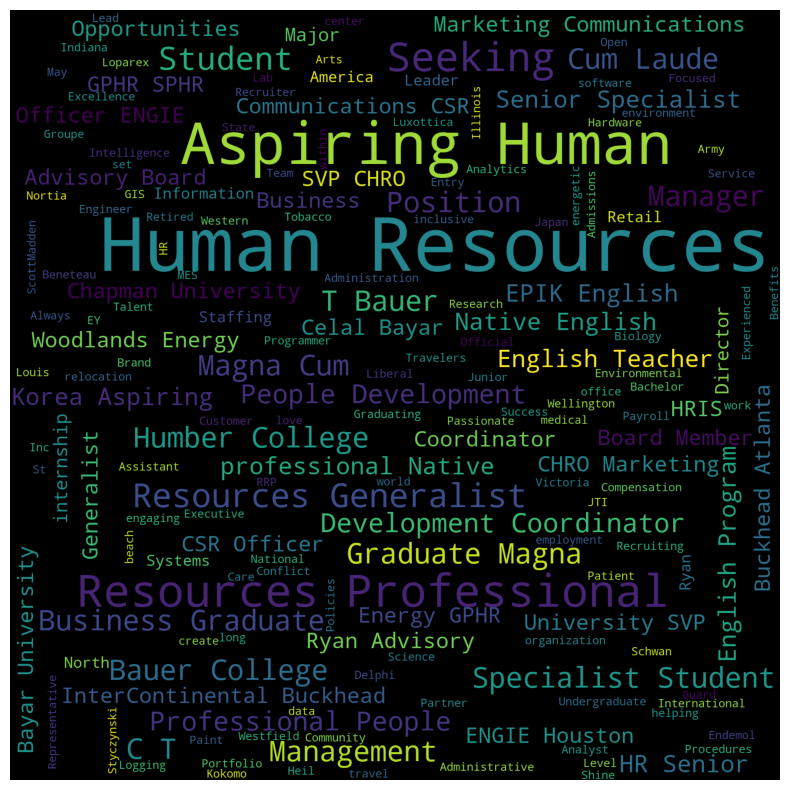

In [5]:
text = " ".join(job_titles)

wordcloud = WordCloud(width=1600, height=1600).generate(text)

plt.subplots(1, 1, figsize=(12,10))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

This visualization highlights the most frequent terms found in the `job_title` field, providing a quick overview of common patterns in candidate roles.

## Vector Search

### Defining keywords

In [6]:
keywords = ['Aspiring human resources','seeking human resources'] 

These are the keywords that will be used to rank potential candidates

### Creating Vectors

In [7]:
# Creating the vectorize object
vectorizer = TfidfVectorizer()

# Creating vector based on the vectorization of the job titles feature
job_titles_matrix = vectorizer.fit_transform(job_titles)

# Creating vector based on the vectorization of the keywords list
keywords_matrix = vectorizer.transform(keywords)

### Getting the Vector Similarity

In [8]:
# Geting a matrix with the similarity score from comparing the job titles and the keywords
resulting_matrix = cosine_similarity(job_titles_matrix, keywords_matrix)

# Getting the max score for all tokens from each candidate
resulting_matrix = resulting_matrix.max(axis=1)

Text data must be converted into numerical vectors to enable similarity comparisons. These vectors are **generated by the vectorizer** and **used with cosine similarity to measure how close texts are**.

Here, the maximum similarity score is selected for each candidate, representing the strongest match between their job title and the provided keywords.

### Adding Similarity Score to Dataframe

In [9]:
# Adding the score data to the fit column
data = data.assign(fit=resulting_matrix)

data.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,0.265312
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,0.000000
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,0.000000
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,0.000000


In [10]:
# Sorting candidates based on the "fit" feature (measures the similarity between the job title and the chosen keywords)
sorted_fit_data = data.sort_values(by=['fit'], ascending=False)

# Printing the top 10 candidates
sorted_fit_data.head(10)

,id,job_title,location,connection,fit
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
32,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
20,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.753591
45,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
23,24,Aspiring Human Resources Specialist,Greater New York City Area,1,0.695679
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,0.695679
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,0.695679


### Keyword Similarity Data

Text(0.5, 1.0, 'Candidates by Job Title Compatibility')

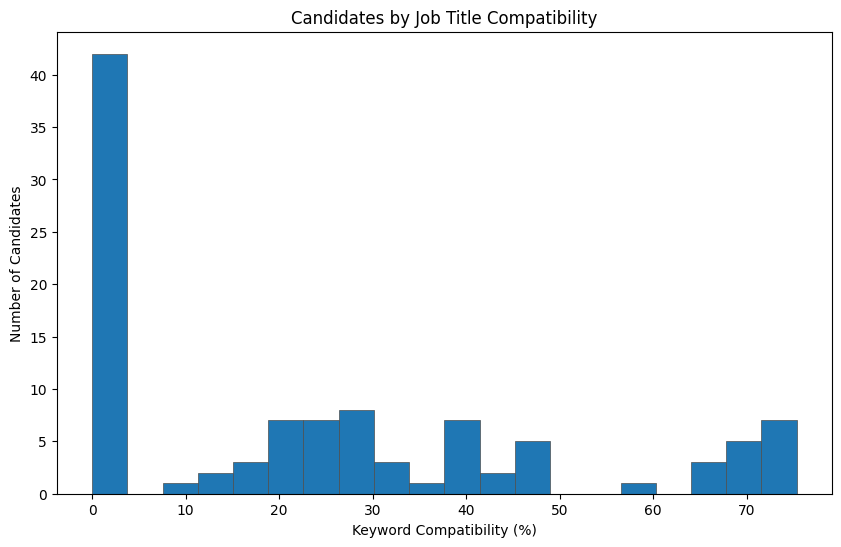

In [11]:
fig = plt.subplots(1, 1, figsize=(10,6))

# Ploting graph that shows the distribution of candiodate's job title compatibility in ralation with the Keywords
plt.hist(data['fit']*100, bins=20, linewidth=.5, edgecolor='.3')

plt.xlabel("Keyword Compatibility (%)")
plt.ylabel("Number of Candidates")
plt.title("Candidates by Job Title Compatibility")

This histogram shows the distribution of keyword compatibility scores across candidates.

**Scores near 0% indicate no meaningful overlap with the keywords, suggesting low relevance**. Higher scores indicate stronger alignment, with **values above 40% representing highly relevant candidates**.

### Filtering Top Candidates

In [12]:
# That's the quantity of candidates that will remain on the dataset in percentage
percentage = 20 # %

highest_scores_quantity = int(len(sorted_fit_data)*(percentage/100))

# Now the sorted dataset only has the (PERCENTAGE)% top fit values
sorted_fit_data = sorted_fit_data[: highest_scores_quantity]

sorted_fit_data.tail(20)

,id,job_title,location,connection,fit
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
32,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
20,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.753591
45,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.753591
23,24,Aspiring Human Resources Specialist,Greater New York City Area,1,0.695679
59,60,Aspiring Human Resources Specialist,Greater New York City Area,1,0.695679
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,0.695679


Only the top `percentage` (**20%** in this case) of candidates are retained for further analysis.

This step **removes low-relevance candidates**, ensuring that subsequent ranking focuses only on the most relevant profiles.

## Features Engineering

In [13]:
# Selecting features that will be used on future comparisons
selected_features = sorted_fit_data[['location','connection','fit']].copy()

# Transforming "connection" to integer format
selected_features['connection'] = selected_features['connection'].map(lambda x: 500 if x == "500+ " else pd.to_numeric(x))

The `connection` feature is originally stored as a string, which prevents numerical operations. This step converts it into an integer format, making it suitable for mathematical processing.

### Transforming Categorical Feature

In [14]:
# Preparing encoder
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

# Encoding "location" using "one hot encoding"
ohe_transformation = ohe.fit_transform(selected_features[['location']])

# Adding the new encoding columns to the dataframe and removing the old "location" column
selected_features = pd.concat([selected_features, ohe_transformation], axis=1).drop(columns='location')

The categorical feature `location` is transformed using One Hot Encoding, converting it into multiple binary columns that can be used in similarity calculations.

### Normalization

In [15]:
# Normalizing the "connection" and "fit" columns (the numeric features)
preprocessor = make_column_transformer(
    (MinMaxScaler(), ['connection', 'fit']),          
    remainder='passthrough'                              
)

# Fiting the normalized selected features in the X variable
X = preprocessor.fit_transform(selected_features)

Normalization **scales numerical features (`connection` and `fit`) to a common range**.

This is **essential for similarity calculations**, as it prevents features with larger values from dominating the results.

## Selecting "Role" Candidate

In [16]:
# Selecting candidate, in this case the 7th candidate
candidate = 7

# The index starts at 0, so we just adjust the index value to be in the correct order
role_idx = candidate - 1 

# Reshaping vector for vector operation (it is now a 1 x features vector
role_vector = X[role_idx].reshape(1, -1)

# Printing the vector for the "role" candidate
selected_features.iloc[role_idx]

connection                                      44.000000
fit                                              0.753591
location_Chicago, Illinois                       0.000000
location_Greater New York City Area              0.000000
location_Greater Philadelphia Area               0.000000
location_Houston, Texas Area                     0.000000
location_Kokomo, Indiana Area                    0.000000
location_Las Vegas, Nevada Area                  0.000000
location_Raleigh-Durham, North Carolina Area     1.000000
Name: 45, dtype: float64

A candidate is **selected as a reference ("role" candidate) to guide the second ranking stage.**

This manual selection may introduce bias. One alternative is to define desired attributes beforehand (e.g., preferred locations or minimum connections), allowing the process to be more objective and automated.

## Sorting Dataframe by "Role" Candidate Similarity

In [17]:
# Get the similarity between ALL candidates in the dataframe and the "role" candidate
selected_features['fit'] = cosine_similarity(X, role_vector).flatten()

# Sort the candidates by "fit" (similarity with "role" candidate)
selected_features = selected_features.sort_values('fit', ascending=False)

# Print the first 10 candidates
selected_features.head(10)

,connection,fit,"location_Chicago, Illinois",location_Greater New York City Area,location_Greater Philadelphia Area,"location_Houston, Texas Area","location_Kokomo, Indiana Area","location_Las Vegas, Nevada Area","location_Raleigh-Durham, North Carolina Area"
2,44,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
32,44,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16,44,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20,44,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
57,44,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
45,44,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0
96,71,0.502641,0.0,0.0,0.0,0.0,1.0,0.0,0.0
23,1,0.440491,0.0,1.0,0.0,0.0,0.0,0.0,0.0
59,1,0.440491,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,1,0.440491,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [18]:
selected_features.tail(10)

,connection,fit,"location_Chicago, Illinois",location_Greater New York City Area,location_Greater Philadelphia Area,"location_Houston, Texas Area","location_Kokomo, Indiana Area","location_Las Vegas, Nevada Area","location_Raleigh-Durham, North Carolina Area"
35,1,0.440491,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48,1,0.440491,0.0,1.0,0.0,0.0,0.0,0.0,0.0
98,48,0.376500,0.0,0.0,0.0,0.0,0.0,1.0,0.0
29,390,0.370913,1.0,0.0,0.0,0.0,0.0,0.0,0.0
27,390,0.370913,1.0,0.0,0.0,0.0,0.0,0.0,0.0
72,7,0.248317,0.0,0.0,0.0,1.0,0.0,0.0,0.0
52,500,0.043006,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,500,0.043006,0.0,0.0,1.0,0.0,0.0,0.0,0.0
39,500,0.043006,0.0,0.0,1.0,0.0,0.0,0.0,0.0
61,500,0.043006,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### "Role" Candidate Compatibility Performance 

Text(0.5, 1.0, "Candidates by 'Role' Candidate Compatibility")

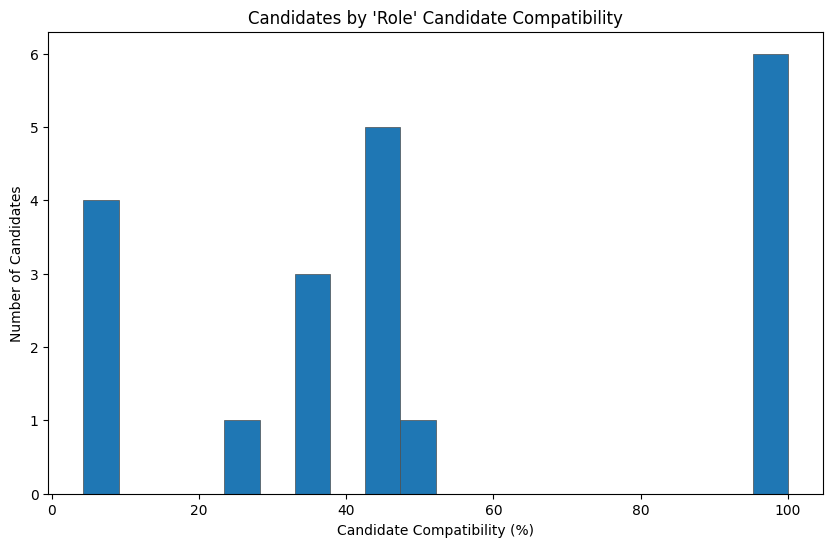

In [19]:
fig = plt.subplots(1, 1, figsize=(10,6))

# Ploting graph that shows the distribution of candiodate's job title compatibility in ralation with the Keywords
plt.hist(selected_features['fit']*100, bins=20, linewidth=.5, edgecolor='.3')

plt.xlabel("Candidate Compatibility (%)")
plt.ylabel("Number of Candidates")
plt.title("Candidates by 'Role' Candidate Compatibility")

This histogram shows the **compatibility of candidates relative to the selected "role" candidate.**

**Higher percentages indicate greater similarity**. Since the dataset was pre-filtered, the number of candidates is lower than the previous graph.